In [37]:
# ── CELL 1: Install & Import Libraries ──
!pip install nltk wordcloud gensim gradio imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re, os, pickle, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, SpatialDropout1D, Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print(" All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


 All libraries imported!
TensorFlow version: 2.20.0


In [38]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
#Load dataset From Drive
df = pd.read_csv('/content/drive/MyDrive/AI and Machine learning/hatevsoffensive_language.csv')
print(df.shape)
print(f"\n Columns: {df.columns.tolist()}")
print(f"\n Class Distribution (BEFORE balancing):")
print(df['label'].value_counts())
print(f"\n Missing Values:")
print(df.isnull().sum())
print(f"\nSample data:")
df.head()

(24783, 2)

 Columns: ['label', 'text']

 Class Distribution (BEFORE balancing):
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

 Missing Values:
label    0
text     0
dtype: int64

Sample data:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [40]:
# ── CELL 4: Text Preprocessing ──
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

contractions = {
    "don't":"do not", "can't":"cannot", "won't":"will not",
    "i'm":"i am", "it's":"it is", "that's":"that is",
    "i've":"i have", "i'll":"i will", "i'd":"i would",
    "you're":"you are", "they're":"they are", "we're":"we are",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "hasn't":"has not", "haven't":"have not",
    "didn't":"did not", "doesn't":"does not", "couldn't":"could not",
    "wouldn't":"would not", "shouldn't":"should not"
}

def expand_contractions(text):
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']
df = df.dropna(subset=['clean_text', 'label'])

print(f" Cleaned dataset: {df.shape[0]} rows")
print("\nBefore vs After cleaning:")
for i in range(3):
    print(f"\n  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")

 Cleaned dataset: 24764 rows

Before vs After cleaning:

  Original : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
  Cleaned  : rt woman complain cleaning house amp man always take trash

  Original : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned  : rt boy dat coldtyga dwn bad cuffin dat hoe st place

  Original : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
  Cleaned  : rt dawg rt ever fuck bitch start cry confused shit


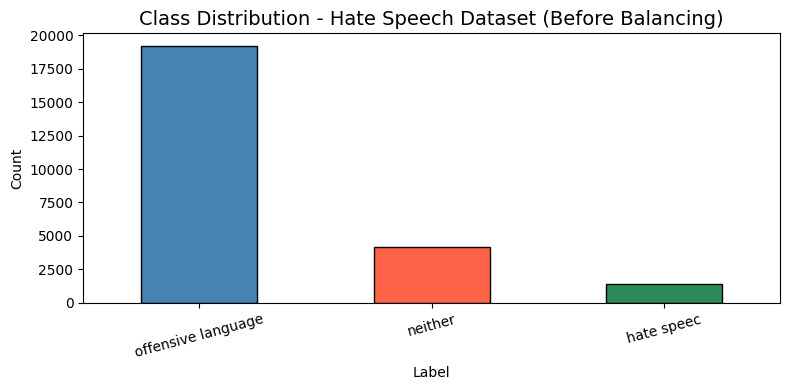

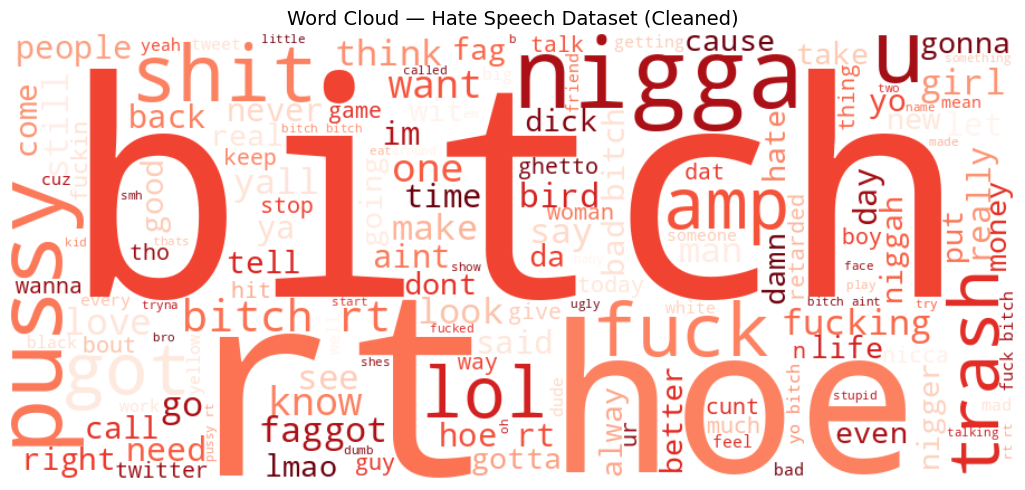

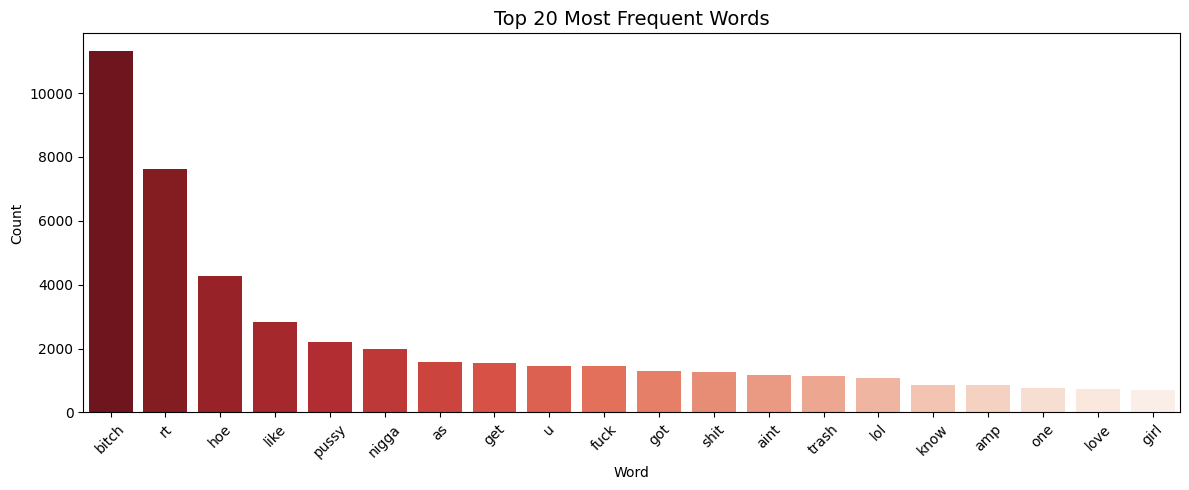

In [41]:
# ── CELL 5: Visualization ──
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar',
    color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
plt.title('Class Distribution - Hate Speech Dataset (Before Balancing)', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

all_text = ' '.join(df['clean_text'].tolist())
wc = WordCloud(width=900, height=400,
               background_color='white',
               colormap='Reds',
               max_words=150).generate(all_text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Hate Speech Dataset (Cleaned)', fontsize=14)
plt.tight_layout()
plt.show()

word_freq = Counter(' '.join(df['clean_text']).split())
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])
plt.figure(figsize=(12, 5))
sns.barplot(data=top_words, x='Word', y='Count', palette='Reds_r')
plt.title('Top 20 Most Frequent Words', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Classes     : ['hate speec' 'neither' 'offensive language']
 Encoded as  : [0, 1, 2]
 Num classes : 3

 Train size : 19811
 Test size  : 4953

 Vocabulary size: 16111
 Max sequence length (95th %ile): 15


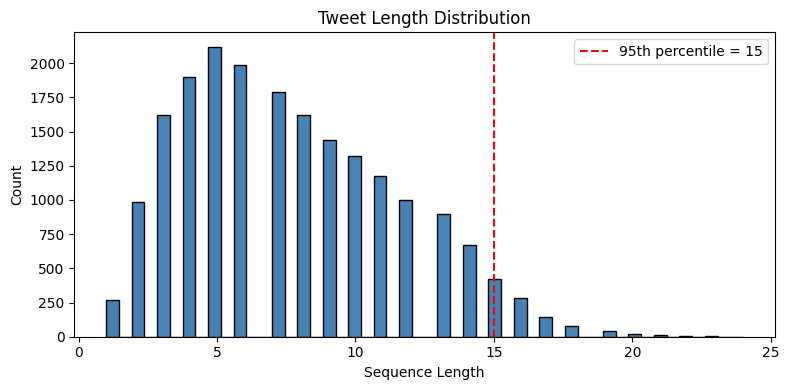


 X_train_pad shape: (19811, 15)
 X_test_pad  shape: (4953, 15)


In [42]:
## ── CELL 6: Tokenization & Padding ──
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
num_classes = df['encoded_label'].nunique()

print(f" Classes     : {le.classes_}")
print(f" Encoded as  : {list(range(num_classes))}")
print(f" Num classes : {num_classes}")

X = df['clean_text'].values
y = df['encoded_label'].values

# 80/20 Train-Test Split (stratified to keep class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train size : {len(X_train)}")
print(f" Test size  : {len(X_test)}")

# Tokenization
vocab_size = 10000
tokenizer  = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
print(f"\n Vocabulary size: {len(word_index)}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding
lengths = [len(s) for s in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f" Max sequence length (95th %ile): {max_len}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th percentile = {max_len}')
plt.title('Tweet Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

print(f"\n X_train_pad shape: {X_train_pad.shape}")
print(f" X_test_pad  shape: {X_test_pad.shape}")

Class distribution BEFORE balancing:
offensive language    15345
neither                3325
hate speec             1141
Name: count, dtype: int64

Class distribution AFTER SMOTE:
offensive language    15345
neither               15345
hate speec            15345
Name: count, dtype: int64

 y_train_cat shape (after SMOTE): (46035, 3)

 Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


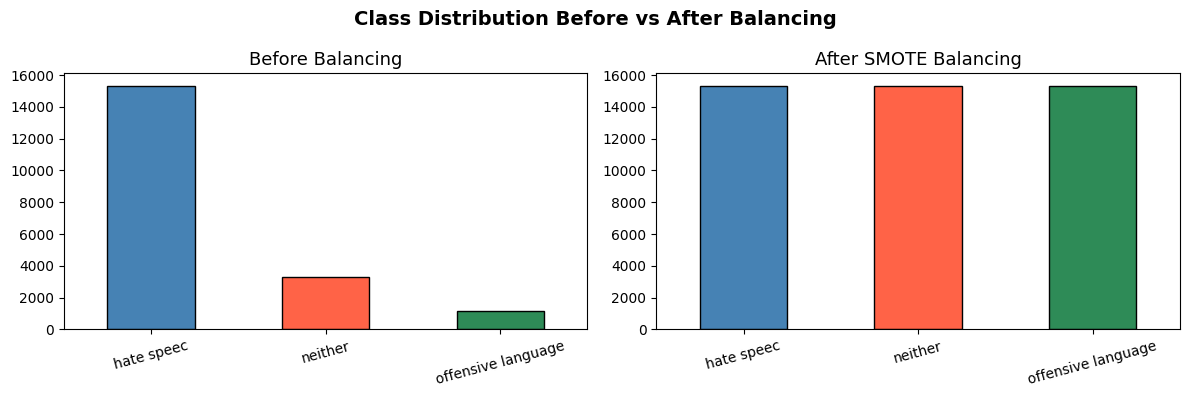

In [43]:
# ── CELL 7: BALANCE THE DATASET (NEW) ──
# ─────────────────────────────────────────────────────────────
# TWO balancing techniques combined:
#   1. SMOTE  — oversample minority classes in feature space
#   2. Class weights — tell model to penalise minority mistakes more
# ─────────────────────────────────────────────────────────────

print("Class distribution BEFORE balancing:")
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(le.classes_))))

# ── Step 1: SMOTE oversampling ──
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_pad, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_bal).value_counts().rename(index=dict(enumerate(le.classes_))))

# One-hot encode the BALANCED labels
y_train_cat = to_categorical(y_train_bal, num_classes)
y_test_cat  = to_categorical(y_test,      num_classes)
print(f"\n y_train_cat shape (after SMOTE): {y_train_cat.shape}")

# ── Step 2: Class weights ──
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_bal),
    y=y_train_bal
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n Class weights: {class_weight_dict}")

# ── Visualise balanced distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[0].set_title('Before Balancing', fontsize=13)
axes[0].set_xticklabels(le.classes_, rotation=15)

pd.Series(y_train_bal).value_counts().plot(
    kind='bar', ax=axes[1],
    color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[1].set_title('After SMOTE Balancing', fontsize=13)
axes[1].set_xticklabels(le.classes_, rotation=15)

plt.suptitle('Class Distribution Before vs After Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# ── CELL 8: Model 1 — Simple RNN ──
embedding_dim = 64

model1 = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, name='embedding'),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model1_SimpleRNN')

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

es = EarlyStopping(monitor='val_loss', patience=3,
                   restore_best_weights=True, verbose=1)

print("\n Training Model 1 - Simple RNN (on BALANCED data)...")
history1 = model1.fit(
    X_train_bal, y_train_cat,        # ← balanced data
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    class_weight=class_weight_dict,  # ← class weights
    verbose=1
)
print(" Model 1 Training Complete!")

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_11            │ (None, 15, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,435 (2.48 MB)

 Trainable params: 650,435 (2.48 MB)

 Non-trainable params: 0 (0.00 B)


 Training Model 1 - Simple RNN (on BALANCED data)...
Epoch 1/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4744 - loss: 1.0123 - val_accuracy: 0.1056 - val_loss: 1.1533
Epoch 2/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5873 - loss: 0.8795 - val_accuracy: 0.3738 - val_loss: 1.0761
Epoch 3/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6258 - loss: 0.8324 - val_accuracy: 0.2937 - val_loss: 1.1699
Epoch 4/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6544 - loss: 0.7985 - val_accuracy: 0.3688 - val_loss: 1.1584
Epoch 5/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6769 - loss: 0.7653 - val_accuracy: 0.3836 - val_loss: 1.1654
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
 Model 1 Training Complete!


In [45]:
# ── CELL 9: Model 2 — LSTM ──
model2 = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, name='embedding'),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model2_LSTM')

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

print("\n Training Model 2 - LSTM (on BALANCED data)...")
history2 = model2.fit(
    X_train_bal, y_train_cat,        # ← balanced data
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    class_weight=class_weight_dict,  # ← class weights
    verbose=1
)
print(" Model 2 Training Complete!")

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_12            │ (None, 15, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,203 (2.58 MB)

 Trainable params: 675,203 (2.58 MB)

 Non-trainable params: 0 (0.00 B)


 Training Model 2 - LSTM (on BALANCED data)...
Epoch 1/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.5737 - loss: 0.8884 - val_accuracy: 0.4787 - val_loss: 1.0639
Epoch 2/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.6741 - loss: 0.7755 - val_accuracy: 0.2804 - val_loss: 1.2226
Epoch 3/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7127 - loss: 0.7095 - val_accuracy: 0.3538 - val_loss: 1.2136
Epoch 4/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7411 - loss: 0.6521 - val_accuracy: 0.3708 - val_loss: 1.2033
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
 Model 2 Training Complete!


In [54]:
# ── CELL 10: Model 3 — LSTM + Word2Vec ──
import gensim.downloader as api

print(" Downloading Word2Vec embeddings (word2vec-google-news-300)...")
print("   This may take 3-5 minutes...")
embedding_model = api.load('word2vec-google-news-300')
word2vec_dim = 300
print(" Word2Vec loaded!")

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, word2vec_dim))   # ← only once here
found = 0
for word, i in word_index.items():
    if i < vocab_size and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

coverage = found / min(vocab_size, len(word_index)) * 100  # ← define coverage
print(f" Words covered by Word2Vec: {found} / {min(vocab_size, len(word_index))} ({coverage:.1f}%)")

model3 = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=word2vec_dim,
              weights=[embedding_matrix],
              trainable=False,
              name='word2vec_embedding'),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='Model3_LSTM_Word2Vec')

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

print("\n Training Model 3 - LSTM + Word2Vec (on BALANCED data)...")
history3 = model3.fit(
    X_train_bal, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    class_weight=class_weight_dict,
    verbose=1
)
print(" Model 3 Training Complete!")

   This may take 3-5 minutes...
 Word2Vec loaded!
 Words covered by Word2Vec: 8128 / 10000 (81.3%)


Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ (None, 15, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_16            │ (None, 15, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,619 (11.81 MB)

 Trainable params: 95,619 (373.51 KB)

 Non-trainable params: 3,000,000 (11.44 MB)


 Training Model 3 - LSTM + Word2Vec (on BALANCED data)...
Epoch 1/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5912 - loss: 0.8798 - val_accuracy: 0.3284 - val_loss: 1.2528
Epoch 2/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6506 - loss: 0.7990 - val_accuracy: 0.3419 - val_loss: 1.1397
Epoch 3/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6632 - loss: 0.7730 - val_accuracy: 0.3579 - val_loss: 1.0843
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
 Model 3 Training Complete!


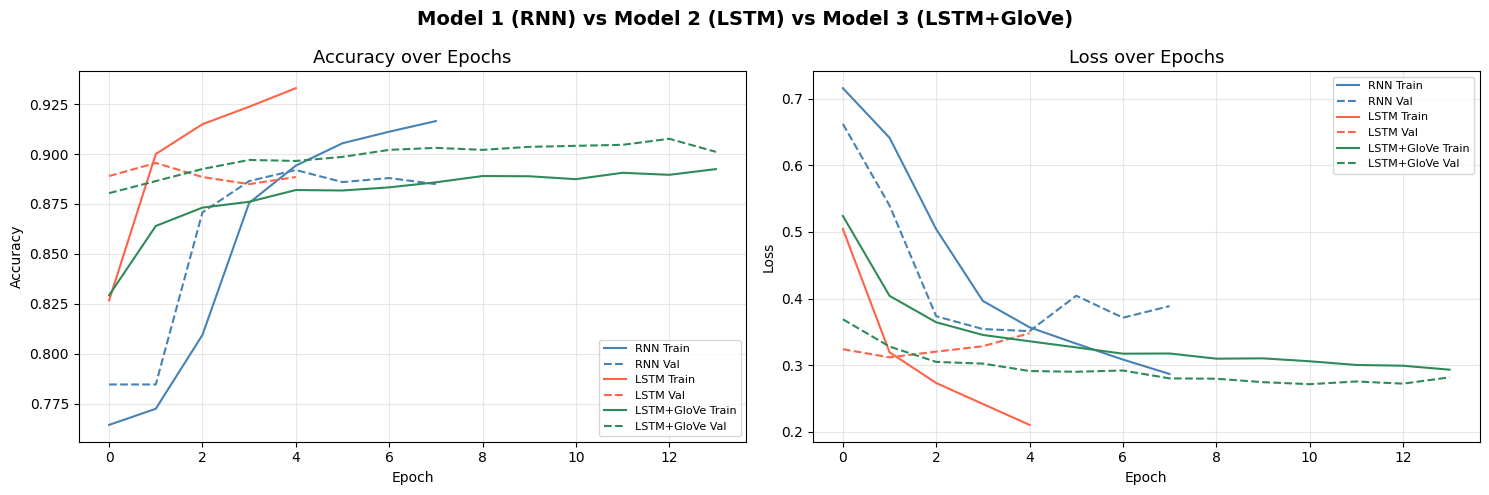

In [24]:
# ── CELL 11: Plot Training Curves ──
def plot_history(h1, h2, h3):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    models = [('RNN', h1, 'steelblue'),
          ('LSTM', h2, 'tomato'),
          ('LSTM+Word2Vec', h3, 'seagreen')]
    for name, h, color in models:
        axes[0].plot(h.history['accuracy'],
                     color=color, label=f'{name} Train')
        axes[0].plot(h.history['val_accuracy'],
                     color=color, linestyle='--', label=f'{name} Val')
        axes[1].plot(h.history['loss'],
                     color=color, label=f'{name} Train')
        axes[1].plot(h.history['val_loss'],
                     color=color, linestyle='--', label=f'{name} Val')

    axes[0].set_title('Accuracy over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Loss over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.suptitle('Model 1 (RNN) vs Model 2 (LSTM) vs Model 3 (LSTM+Word2Vec)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history1, history2, history3)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

   Model 1 — Simple RNN
  Accuracy    : 0.7638 (76.38%)
  Macro F1    : 0.5694   ← key metric for imbalanced data
  Weighted F1 : 0.8008

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.14      0.40      0.21       285
           neither       0.58      0.65      0.61       832
offensive language       0.97      0.82      0.89      3836

          accuracy                           0.76      4953
         macro avg       0.56      0.62      0.57      4953
      weighted avg       0.86      0.76      0.80      4953



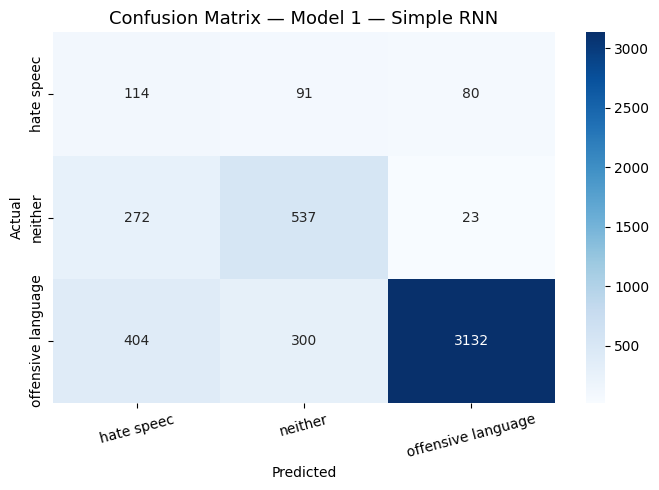

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

   Model 2 — LSTM
  Accuracy    : 0.8344 (83.44%)
  Macro F1    : 0.6717   ← key metric for imbalanced data
  Weighted F1 : 0.8508

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.25      0.46      0.33       285
           neither       0.70      0.88      0.78       832
offensive language       0.96      0.85      0.90      3836

          accuracy                           0.83      4953
         macro avg       0.64      0.73      0.67      4953
      weighted avg       0.88      0.83      0.85      4953



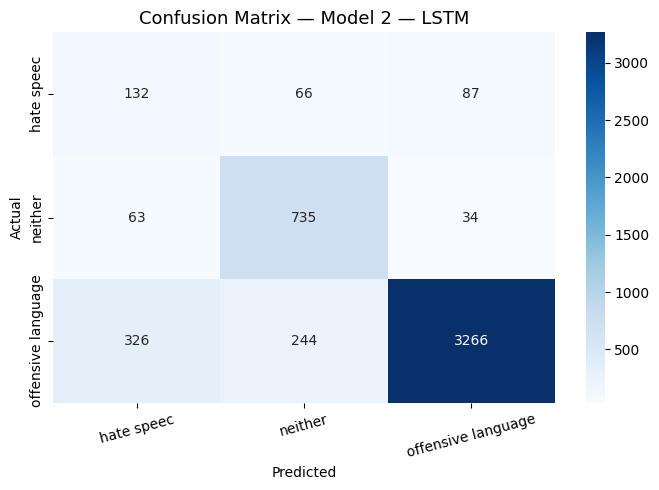

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

   Model 3 — LSTM + GloVe
  Accuracy    : 0.8074 (80.74%)
  Macro F1    : 0.6364   ← key metric for imbalanced data
  Weighted F1 : 0.8411

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.17      0.50      0.26       285
           neither       0.81      0.70      0.75       832
offensive language       0.96      0.85      0.90      3836

          accuracy                           0.81      4953
         macro avg       0.65      0.68      0.64      4953
      weighted avg       0.89      0.81      0.84      4953



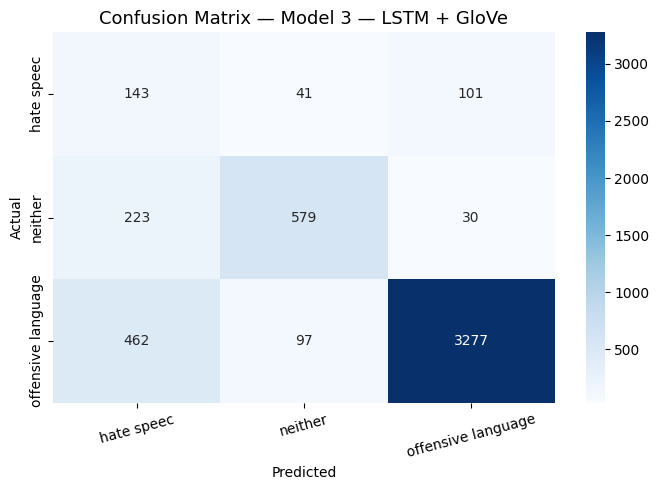


   FINAL MODEL COMPARISON SUMMARY
  Model                       Accuracy   Macro F1
  --------------------------------------------------
  Simple RNN                    76.38%     0.5694
  LSTM                          83.44%     0.6717
  LSTM + GloVe                  80.74%     0.6364
  Note: Macro F1 is the reliable metric here
        because the dataset was imbalanced.


In [48]:

# ── CELL 12: Evaluate All Models (with Macro F1) ──
def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = y_test

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"   {name}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Macro F1    : {f1:.4f}   ← key metric for imbalanced data")
    print(f"  Weighted F1 : {f1_w:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
          target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    return y_pred, y_true, acc, f1


pred1, true1, acc1, f1_1 = evaluate_model(model1, 'Model 1 — Simple RNN')
pred2, true2, acc2, f1_2 = evaluate_model(model2, 'Model 2 — LSTM')
pred3, true3, acc3, f1_3 = evaluate_model(model3, 'Model 3 — LSTM + Word2Vec')

# ── Final Summary Table ──
print("\n" + "="*54)
print("   FINAL MODEL COMPARISON SUMMARY")
print("="*54)
print(f"  {'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print(f"  {'-'*50}")
print(f"  {'Simple RNN':<25} {acc1*100:>9.2f}%  {f1_1:>9.4f}")
print(f"  {'LSTM':<25} {acc2*100:>9.2f}%  {f1_2:>9.4f}")
print(f"  {'LSTM + Word2Vec':<25} {acc3*100:>9.2f}%  {f1_3:>9.4f}")
print("="*54)
print("  Note: Macro F1 is the reliable metric here")
print("        because the dataset was imbalanced.")

In [50]:
# ── CELL 13: Error Analysis ──
print(" ERROR ANALYSIS — Model 3 (LSTM + Word2Vec)\n")

errors_idx = np.where(pred3 != true3)[0]
print(f"Total misclassified: {len(errors_idx)} / {len(true3)}")

print("\n── 3 Sample Misclassifications ──\n")
for i, idx in enumerate(errors_idx[:3]):
    print(f"Example {i+1}:")
    print(f"  Tweet (original) : {X_test[idx]}")
    print(f"  True Label       : {le.classes_[true3[idx]]}")
    print(f"  Predicted Label  : {le.classes_[pred3[idx]]}")
    print(f"  Possible Reason  : Ambiguous language or sarcasm\n")

 ERROR ANALYSIS — Model 3 (LSTM + GloVe)

Total misclassified: 954 / 4953

── 3 Sample Misclassifications ──

Example 1:
  Tweet (original) : stop trying honky
  True Label       : offensive language
  Predicted Label  : hate speec
  Possible Reason  : Ambiguous language or sarcasm

Example 2:
  Tweet (original) : like tattoo head form mullet white trash people entertaining sometimes
  True Label       : offensive language
  Predicted Label  : hate speec
  Possible Reason  : Ambiguous language or sarcasm

Example 3:
  Tweet (original) : hungry ferkin nip
  True Label       : offensive language
  Predicted Label  : hate speec
  Possible Reason  : Ambiguous language or sarcasm



In [27]:
#Real-Time GUI (Gradio)
!pip install gradio -q
import gradio as gr

def predict_hate_speech(tweet):
    if not tweet.strip():
        return " Please enter a tweet."
    cleaned = clean_text(tweet)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len,
                            padding='post', truncating='post')
    prob    = model3.predict(padded)[0]
    pred_class  = np.argmax(prob)
    label       = le.classes_[pred_class]
    confidence  = float(prob[pred_class])

    emoji = {"hate speech": "", "offensive language": "", "neither": ""}
    return (f"{emoji.get(label,'')} **{label.upper()}**\n\n"
            f"Confidence: {confidence:.2%}\n\n"
            f"Probabilities:\n"
            f"  Hate Speech        : {prob[0]:.2%}\n"
            f"  Neither            : {prob[1]:.2%}\n"
            f"  Offensive Language : {prob[2]:.2%}")

demo = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(lines=3,
                      placeholder="Type a tweet here...",
                      label="Input Tweet"),
    outputs=gr.Markdown(label="Prediction"),
    title=" Hate Speech Detector",
    description="Detects whether a tweet is Hate Speech, Offensive Language, or Neither.\nModel: LSTM + Word2Vec Embeddings"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e53d9224bb1db18ba6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [51]:
# ── CELL 15: Save Everything to Drive ──
save_dir = '/content/drive/MyDrive/AI and Machine learning/HateSpeech_Models/'
os.makedirs(save_dir, exist_ok=True)

model1.save(save_dir + 'model1_rnn_balanced.h5')
model2.save(save_dir + 'model2_lstm_balanced.h5')
model3.save(save_dir + 'model3_lstm_word2vec_balanced.h5')

with open(save_dir + 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open(save_dir + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(" All balanced models saved to Google Drive!")
print(f"   {save_dir}")

 All balanced models saved to Google Drive!
   /content/drive/MyDrive/AI and Machine learning/HateSpeech_Models/
